In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles')
import funciones_aux_bootstrap as fab

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


Este método de bootstrap (bayesiano) por votos consiste en lo siguiente

1. Se muestrea $n$ casillas.
2. De las $n$ casillas se muestrean $k$ votos para cada una de las $(1000)$ poblaciones distintas. Es decir, se obtiene un total de $1000$ muestras distintas de votos.
3. Para cada población y cada una de las $1000$ muestras de votos de tamaño $k$ se calculan los pesos Dirichlet, por lo tanto, se calculan en total $k*1000$ distintos pesos Dirichlet.
4. Se completan $1000$ poblaciones.
5. Con las poblaciones se obtienen la estimación puntual.

Se repite este proceso para $l$ bootstraps (normalmente son 1000) y con estos bootstraps se obtienen todas las métricas (errores, tamaño de los intervalos, coberturas, etc).

In [16]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [17]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

## Sin estratificar

In [18]:
def bootstrap_votos_simple_met_2(df, num_boot: int=1000, n_sample=None, n_vot_sub=2000):

    est_punt_list=[]

    inter_list=[]

    # Número total de votos
    n_votos=int(df[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum())

    # Semilla para las muestras de la Dirichlet
    rng = np.random.default_rng()

    # Semilla para los conteos de votos (eventualmente se tiene que mover adentro del for para que sea reproducible el código)
    rng_2 = np.random.default_rng()

    for i in range(num_boot):


        df_stra_sam = df.sample(n=n_sample)

        df_stra_sam=np.array(df_stra_sam[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Votos por candidato en la muestra
        n_votos_cand=df_stra_sam.sum(0).astype(int)
 
        # Submuestra de votos (en este caso son 2000)
        # Corrección del código inicial lo correcto es utilizar la distribución hipergeométrica multivariada.
        # Puesto que, se esta haciendo muestreo sin reemplazo y si utilizas la multinomial es muestreo con reemplazo.
        # La diferencia es mínima pero la hipergeométrica multivariada es la correcta.
        # Sacamos 1000 muestras distintas
        votos_subm=rng.multivariate_hypergeometric(colors=df_stra_sam.sum(0).astype(int), nsample=n_vot_sub, size=1000)

        # Los pesos de la distribución Dirichlet para las 1000 muestras distintas
        pesos_bootstrap=fab.dirichlet_sample(votos_subm)

        # Simulamos las 1000 poblaciones de votos
        votos_sim=rng_2.multinomial(n=n_votos,  pvals=pesos_bootstrap)

        # Obtenemos las proporciones de los votos
        array_res=(votos_sim)/n_votos

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))
        
        # Estimaciones puntuales
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)
        
    print(df_stra_sam.shape[0])
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)

    return array_inter_prob,array_est_punt


In [26]:
# Boostrap por votos
inter_prob_v, est_punt_v=bootstrap_votos_simple_met_2(df_act_yuc_i, num_boot=1000, n_sample=250, n_vot_sub=2000)

250


In [21]:
# Para medir cuanto tiempo se tarda en correr en promedio
#%timeit bootstrap_votos_simple_met_2(df_act_yuc_i, num_boot=1000, n_sample=350, n_vot_sub=5000)

In [27]:
# Guardamos las bases
df_metr_boot_v, df_error_max_v, df_can_cob_v = fab.metricas_bootstrap(prop_reales, inter_prob_v, est_punt_v, porcenta_tama=2000)

In [28]:
df_can_cob_v

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,999,0.999,2000
1,RENAN_BARRERA_CONCHA,998,0.998,2000
2,VIDA_ARAVARI_GOMEZ_HERRERA,1000,1.000,2000
3,VOTOS_NULOS_CAND_NO_REGIS,1000,1.000,2000
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,1000,1.000,2000


In [29]:
df_error_max_v.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.007724,2000.0
std,288.819436,0.005148,0.0
min,1.000000,0.000502,2000.0
2.5%,25.975000,0.001181,2000.0
50%,500.500000,0.006623,2000.0
97.5%,975.025000,0.020015,2000.0
max,1000.000000,0.034316,2000.0


In [ ]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v=df_metr_boot_v.drop(columns="Cobertura").merge(df_can_cob_v[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.500934,0.539530,0.038597,0.520057,0.515125,JOAQUIN_DIAZ_MENA,0.004931,250,0.993
1,2,0.498908,0.537580,0.038672,0.518588,0.515125,JOAQUIN_DIAZ_MENA,0.003463,250,0.993
2,3,0.499795,0.536926,0.037132,0.517986,0.515125,JOAQUIN_DIAZ_MENA,0.002860,250,0.993
3,4,0.493333,0.532270,0.038937,0.513111,0.515125,JOAQUIN_DIAZ_MENA,0.002015,250,0.993
4,5,0.503355,0.539387,0.036032,0.521709,0.515125,JOAQUIN_DIAZ_MENA,0.006584,250,0.993
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.015532,0.026582,0.011050,0.020763,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000704,250,1.000
4996,997,0.014709,0.025144,0.010435,0.019535,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001933,250,1.000
4997,998,0.016700,0.028122,0.011422,0.022067,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000600,250,1.000
4998,999,0.015447,0.026751,0.011304,0.020854,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000613,250,1.000


In [ ]:
# Candidato con intervalo más largo
df_inter_lar_v=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v["Porcenta_tama"]=250
candidato_mas_largo_v=df_inter_lar_v[df_inter_lar_v["Longitud_intervalo"]==df_inter_lar_v["Longitud_intervalo"].max()]["Candidato"].values[0]
df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v]["Longitud_intervalo"].describe(percentiles=[0.025, 0.5, 0.975])

count    1000.000000
mean        0.038722
std         0.001212
min         0.034399
2.5%        0.036395
50%         0.038701
97.5%       0.041156
max         0.044558
Name: Longitud_intervalo, dtype: float64

In [ ]:
# Candidato con intervalo más largo
df_inter_lar_v=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v["Porcenta_tama"]=250
candidato_mas_largo_v=df_inter_lar_v[df_inter_lar_v["Longitud_intervalo"]==df_inter_lar_v["Longitud_intervalo"].max()]["Candidato"].values[0]

In [ ]:
# Candidato con menor cobertura
candidato_cober_men_v=df_can_cob_v[df_can_cob_v["Cobertura"]==df_can_cob_v["Cobertura"].min()]["Candidato"].values[0]

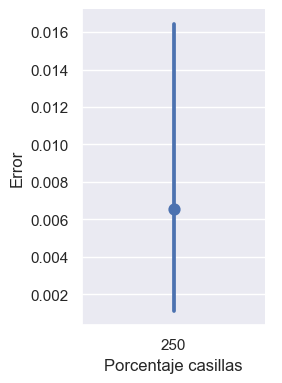

In [ ]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [ ]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v=df_metr_boot_v.drop(columns="Cobertura").merge(df_can_cob_v[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.500934,0.539530,0.038597,0.520057,0.515125,JOAQUIN_DIAZ_MENA,0.004931,250,0.993
1,2,0.498908,0.537580,0.038672,0.518588,0.515125,JOAQUIN_DIAZ_MENA,0.003463,250,0.993
2,3,0.499795,0.536926,0.037132,0.517986,0.515125,JOAQUIN_DIAZ_MENA,0.002860,250,0.993
3,4,0.493333,0.532270,0.038937,0.513111,0.515125,JOAQUIN_DIAZ_MENA,0.002015,250,0.993
4,5,0.503355,0.539387,0.036032,0.521709,0.515125,JOAQUIN_DIAZ_MENA,0.006584,250,0.993
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.015532,0.026582,0.011050,0.020763,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000704,250,1.000
4996,997,0.014709,0.025144,0.010435,0.019535,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001933,250,1.000
4997,998,0.016700,0.028122,0.011422,0.022067,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000600,250,1.000
4998,999,0.015447,0.026751,0.011304,0.020854,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000613,250,1.000


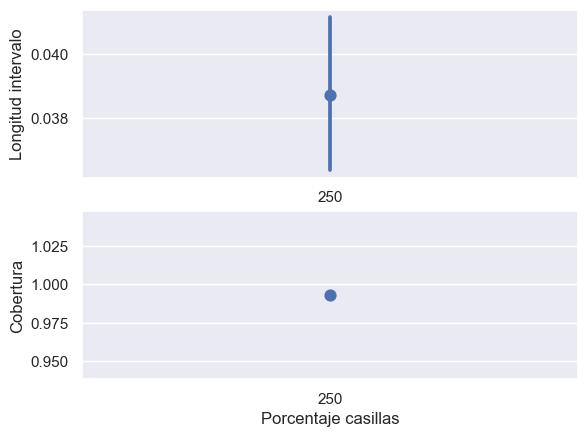

In [ ]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


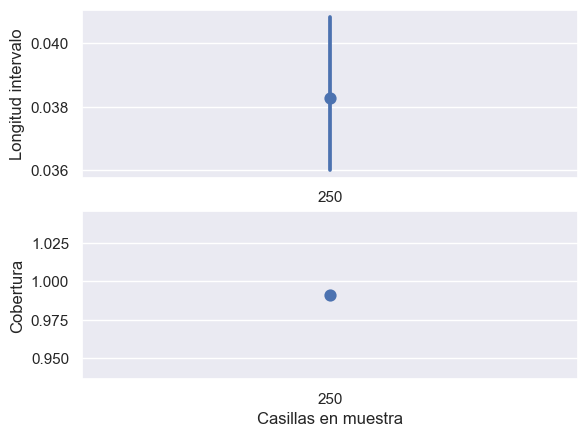

In [ ]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Casillas en muestra', ylabel='Longitud intervalo');
ax_2.set(xlabel='Casillas en muestra', ylabel='Cobertura');

In [ ]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
muestra_casillas = [100, 150, 200, 250, 300, 350, 400]
#submuestra_votos = [500, 1000, 1500, 2000, 3000, 4000]

# Edición especial con otras submuestras de votos
submuestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Dataframe donde se guardará todo
df_boostraps_votos_se=pd.DataFrame()

# Contador para el for
k=0

for mc in muestra_casillas:
    for smv in submuestra_votos:
        # Boostrap por votos (sin estratificar)
        inter_prob_v, est_punt_v=bootstrap_votos_simple_met_2(df_act_yuc_i, num_boot=1000, n_sample=mc, n_vot_sub=smv)
        # Calculamos las métricas
        df_metr_boot_v, df_error_max_v, df_can_cob_v = fab.metricas_bootstrap(prop_reales, inter_prob_v, est_punt_v, porcenta_tama=mc)

        # Los valores de las muestra y submuestras
        df_boostraps_votos_se.loc[k,["Tamaño_muestra_casillas","Tamaño_submuestra_votos"]]=[mc,smv]

        # Las métricas para el error máximo
        df_boostraps_votos_se.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max_v["Error_max"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato que tenga intervalos más largos (en promedio)
        candidato_int_m_l=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
        # Candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_m_l
        # Cobertura del candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob_v[df_can_cob_v["Candidato"]==candidato_int_m_l]["Cobertura"].values[0]
        # Las métricas del candidato con los intervalos más grandes
        df_boostraps_votos_se.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot_v[df_metr_boot_v["Candidato"]==candidato_int_m_l]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato con la menor cobertura
        # Candidato con menor cobertura
        candidato_cober_men_v=df_can_cob_v[df_can_cob_v["Cobertura"]==df_can_cob_v["Cobertura"].min()]["Candidato"].values[0]

        # Candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_men_v
        # Cobertura del candidato con menor cobertura
        df_boostraps_votos_se.loc[k, ["Cobertura_m_candidato"]]=df_can_cob_v[df_can_cob_v["Candidato"]==candidato_cober_men_v]["Cobertura"].values[0]
        # Las métricas del candidato con la menor cobertura
        df_boostraps_votos_se.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot_v[df_metr_boot_v["Candidato"]==candidato_cober_men_v]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        
        # Coberturas de los candidatos en el bootstrap 
        df_boostraps_votos_se.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob_v.sort_values(by="Candidato")["Cobertura"].to_list()

        k=k+1
        
        print("Muestra casillas:", mc, "Submuestra votos:", smv)

100
Muestra casillas: 100 Submuestra votos: 500
100
Muestra casillas: 100 Submuestra votos: 1000
100
Muestra casillas: 100 Submuestra votos: 2000
100
Muestra casillas: 100 Submuestra votos: 5000
100
Muestra casillas: 100 Submuestra votos: 10000
100
Muestra casillas: 100 Submuestra votos: 20000
150
Muestra casillas: 150 Submuestra votos: 500
150
Muestra casillas: 150 Submuestra votos: 1000
150
Muestra casillas: 150 Submuestra votos: 2000
150
Muestra casillas: 150 Submuestra votos: 5000
150
Muestra casillas: 150 Submuestra votos: 10000
150
Muestra casillas: 150 Submuestra votos: 20000
200
Muestra casillas: 200 Submuestra votos: 500
200
Muestra casillas: 200 Submuestra votos: 1000
200
Muestra casillas: 200 Submuestra votos: 2000
200
Muestra casillas: 200 Submuestra votos: 5000
200
Muestra casillas: 200 Submuestra votos: 10000
200
Muestra casillas: 200 Submuestra votos: 20000
250
Muestra casillas: 250 Submuestra votos: 500
250
Muestra casillas: 250 Submuestra votos: 1000
250
Muestra casill

In [ ]:
df_boostraps_votos_se

,Tamaño_muestra_casillas,Tamaño_submuestra_votos,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE
0,100,500,0.002026,0.010596,0.032842,JOAQUIN_DIAZ_MENA,1.000,0.115445,0.122616,0.129936,JOAQUIN_DIAZ_MENA,1.000,0.115445,0.122616,0.129936,1.000,1.000,1.000,1.000,1.000
1,100,1000,0.002171,0.010937,0.033091,JOAQUIN_DIAZ_MENA,0.997,0.081793,0.086440,0.092104,RENAN_BARRERA_CONCHA,0.995,0.080660,0.085519,0.091119,0.997,0.995,1.000,1.000,1.000
2,100,2000,0.001964,0.011623,0.030306,JOAQUIN_DIAZ_MENA,0.980,0.057459,0.060825,0.064419,RENAN_BARRERA_CONCHA,0.976,0.056588,0.060032,0.063819,0.980,0.976,0.996,1.000,0.998
3,100,5000,0.002260,0.011638,0.032488,JOAQUIN_DIAZ_MENA,0.833,0.035588,0.037882,0.040030,RENAN_BARRERA_CONCHA,0.801,0.035222,0.037424,0.039566,0.833,0.801,0.928,0.984,0.972
4,100,10000,0.001994,0.010702,0.033313,JOAQUIN_DIAZ_MENA,0.687,0.024486,0.025976,0.027614,RENAN_BARRERA_CONCHA,0.655,0.024230,0.025666,0.027065,0.687,0.655,0.800,0.966,0.901
5,100,20000,0.002134,0.011259,0.033018,JOAQUIN_DIAZ_MENA,0.494,0.016221,0.017176,0.018150,RENAN_BARRERA_CONCHA,0.443,0.015993,0.016980,0.018007,0.494,0.443,0.586,0.906,0.667
6,150,500,0.001565,0.009169,0.026328,JOAQUIN_DIAZ_MENA,1.000,0.115808,0.122560,0.130301,JOAQUIN_DIAZ_MENA,1.000,0.115808,0.122560,0.130301,1.000,1.000,1.000,1.000,1.000
7,150,1000,0.001695,0.009242,0.026605,JOAQUIN_DIAZ_MENA,1.000,0.081714,0.086770,0.092302,JOAQUIN_DIAZ_MENA,1.000,0.081714,0.086770,0.092302,1.000,1.000,1.000,1.000,1.000
8,150,2000,0.001680,0.009094,0.025627,JOAQUIN_DIAZ_MENA,0.997,0.057425,0.061184,0.064858,RENAN_BARRERA_CONCHA,0.995,0.056924,0.060277,0.063722,0.997,0.995,1.000,1.000,1.000
9,150,5000,0.001805,0.008792,0.026785,JOAQUIN_DIAZ_MENA,0.913,0.036022,0.038275,0.040622,RENAN_BARRERA_CONCHA,0.907,0.035720,0.037826,0.040163,0.913,0.907,0.974,0.998,0.997


In [ ]:
# Guardamos en un csv
df_boostraps_votos_se.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Bootstrap votos/Metodo 2/Distintas_muestras_submuestras_bootstrap_votos_met_2_sin_est_4_ed_e.csv")

## Estratificado (por distrito)

In [30]:
# Versión función
def boot_votos_estratificado_met_2(df_act_yuc_i, num_boot: int=1000, n_sample=None, frac=None, n_vot_sub=2000):

    # Listas auxiliares para guardar los datos
    est_punt_list=[]

    inter_list=[]

    # Cuantas votos hay por distrito
    array_frec_est=np.array(df_act_yuc_i.groupby('DISTRITO').agg({'TOTAL':'sum'}).reset_index(drop=True).astype(int)["TOTAL"])

    # Número de poblaciones
    n_boot=1000

    # Semilla para las muestras de la Dirichlet
    rng = np.random.default_rng()

    # Semilla para las muestras de la Dirichlet
    rng_2 = np.random.default_rng()

    # Los valores distintos de los distritos
    val_dist=df_act_yuc_i["DISTRITO"].sort_values().unique()

    for i in range(num_boot):

        # Hacemos el muestreo estratificado
        if n_sample==None:
            # Hacemos el muestreo de frac de las casilas estratificado por distrito
            X_train, df_stra_sam = train_test_split(df_act_yuc_i[["DISTRITO","ID CASILLA","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS","TOTAL"]], stratify=df_act_yuc_i['DISTRITO'], test_size=frac)
        else:
            # Hacemos el muestreo de tamaño n_sample de las casilas estratificado por distrito
            df_stra_sam=fab.muestreo_estratificado_mej(df_act_yuc_i, ["DISTRITO"], sample_size=n_sample, seed=None)

        # Guardamos en un numpy array el dataframe de la muestra
        array_muest=np.array(df_stra_sam[["DISTRITO","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Los valores distintos de los distritos
        #val_dist=df_stra_sam["DISTRITO"].sort_values().unique()

        # Sirve para calcular el número de votos por estrato (distrito) en la muestra (tal vez sirva para después)
        #valores_votos_dist=[array_muest[array_muest[:,0]==val][:,1:].sum(0).sum(0).astype(int) for val in val_dist]

        # Los porcentajes de cada distrito en la muestra
        #array_pesos_normalizados_dist=np.array(df_stra_sam["DISTRITO"].value_counts(normalize=True).sort_index())

        # Corrección porque el muestreo estratificado es de votos
        # Porcentaje del total de votos por estrato (distrito)
        array_pesos_normalizados_dist=np.array(df_stra_sam.groupby('DISTRITO').agg({'TOTAL':'sum'}).div(df_stra_sam["TOTAL"].sum()).sort_index()["TOTAL"])

        # Obtenemos los totales de las proporciones para cada estrato (distrito)
        #totales_prop_est=fab.obtener_totales(array_pesos_normalizados_dist, n_vot_sub)
        totales_prop_est=fab.obtener_totales(array_pesos_normalizados_dist, n_vot_sub).astype(int)

        # Los porcentajes de cada distrito en la submuestra de votos
        array_pesos_normalizados_sub=totales_prop_est/totales_prop_est.sum()

        #votos_subm=rng.multivariate_hypergeometric(colors=df_stra_sam.sum(0).astype(int), nsample=n_vot_sub, size=1)[0]

        # Submuestra de votos por distrito (estrato)
        # Corrección del código inicial lo correcto es utilizar la distribución hipergeométrica multivariada.
        # Puesto que, se esta haciendo muestreo sin reemplazo y si utilizas la multinomial es muestreo con reemplazo.
        # La diferencia es mínima pero la hipergeométrica multivariada es la correcta.
        votos_subm_d=[rng.multivariate_hypergeometric(colors=array_muest[array_muest[:,0]==val][:,1:].sum(0).astype(int), nsample=totales_prop_est[val-1], size=1000) for val in val_dist]

        # Vector de pesos de la distribución Dirichlet

        # Obtenemos los vectores Dirichlet para cada uno de los estratos
        vectores_dir=[fab.dirichlet_sample(xi) for xi in votos_subm_d]

        # Donde se van a guardar los resultados
        array_res=np.zeros((n_boot,5))

        # Completamos la muestra mediante el bootstrap bayesiano en cada estrato
        for k in val_dist:
            
            # Total de votos de la muestra simulada (utilizando una multinomial)
            votos_sim=rng_2.multinomial(n=array_frec_est[k-1],  pvals=vectores_dir[k-1])

            # Guardamos todo en un array con las estimaciones (se van sumando las iteraciones para alcnazar el 100%)
            array_res=array_res+(votos_sim/votos_sim.sum(1)[0]*array_pesos_normalizados_sub[k-1])
                
        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))

        # Estimaciones puntuales (del bootstrap)
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)


    print(df_stra_sam.shape[0])
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)
    
    return array_inter_prob,array_est_punt


In [46]:
inter_prob_v_est, est_punt_v_est=boot_votos_estratificado_met_2(df_act_yuc_i, num_boot=1000, n_sample=250, n_vot_sub=2000)

250


In [47]:
# Para medir cuanto tiempo se tarda en correr en promedio
#%timeit boot_votos_estratificado_met_2(df_act_yuc_i, num_boot=1000, n_sample=250, n_vot_sub=2000)

In [48]:
# Cálculamos las métricas
df_metr_boot_v_est, df_error_max_v_est, df_can_cob_v_est = fab.metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=2000)

In [49]:
df_can_cob_v_est

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,1000,1.0,2000
1,RENAN_BARRERA_CONCHA,1000,1.0,2000
2,VIDA_ARAVARI_GOMEZ_HERRERA,1000,1.0,2000
3,VOTOS_NULOS_CAND_NO_REGIS,1000,1.0,2000
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,1000,1.0,2000


In [ ]:
# Candidato con intervalo más largo
df_inter_lar_v_est=df_metr_boot_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v_est["Porcenta_tama"]=250
candidato_mas_largo_v_est=df_inter_lar_v_est[df_inter_lar_v_est["Longitud_intervalo"]==df_inter_lar_v_est["Longitud_intervalo"].max()]["Candidato"].values[0]

In [ ]:
# Candidato con menor cobertura
candidato_cober_men_v_est=df_can_cob_v_est[df_can_cob_v_est["Cobertura"]==df_can_cob_v_est["Cobertura"].min()]["Candidato"].values[0]

In [50]:
df_error_max_v_est.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.006354,2000.0
std,288.819436,0.003948,0.0
min,1.000000,0.000186,2000.0
2.5%,25.975000,0.001163,2000.0
50%,500.500000,0.005459,2000.0
97.5%,975.025000,0.015875,2000.0
max,1000.000000,0.022722,2000.0


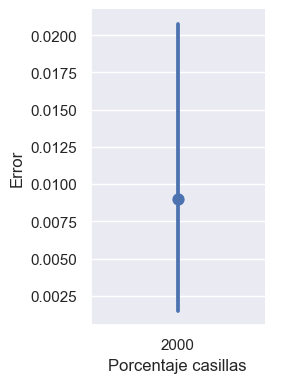

In [ ]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v_est, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [ ]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v_est=df_metr_boot_v_est.drop(columns="Cobertura").merge(df_can_cob_v_est[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v_est

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.483439,0.545137,0.061698,0.514090,0.515125,JOAQUIN_DIAZ_MENA,0.001036,2000,1.0
1,2,0.489626,0.548447,0.058821,0.518974,0.515125,JOAQUIN_DIAZ_MENA,0.003848,2000,1.0
2,3,0.505217,0.564621,0.059404,0.533615,0.515125,JOAQUIN_DIAZ_MENA,0.018490,2000,1.0
3,4,0.487398,0.545694,0.058296,0.515338,0.515125,JOAQUIN_DIAZ_MENA,0.000212,2000,1.0
4,5,0.495107,0.554717,0.059610,0.524354,0.515125,JOAQUIN_DIAZ_MENA,0.009228,2000,1.0
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.013899,0.031260,0.017362,0.021950,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000483,2000,1.0
4996,997,0.014279,0.032357,0.018078,0.022751,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001284,2000,1.0
4997,998,0.012942,0.029950,0.017008,0.020905,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000562,2000,1.0
4998,999,0.012855,0.029553,0.016698,0.020379,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001088,2000,1.0


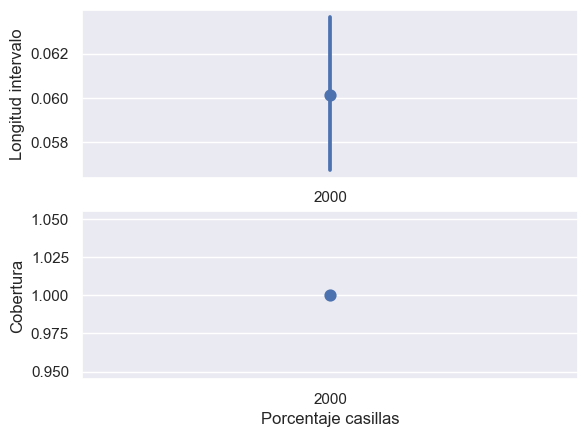

In [ ]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


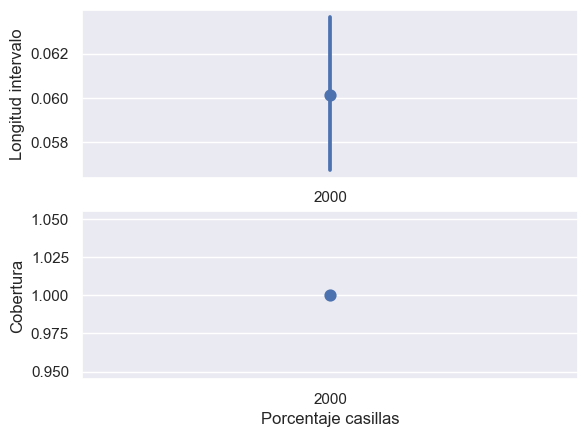

In [ ]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');

In [ ]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
muestra_casillas = [100, 150, 200, 250, 300, 350, 400]
#submuestra_votos = [500, 1000, 1500, 2000, 3000, 4000]

# Edición especial con otras submuestras de votos
submuestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Dataframe donde se guardará todo
df_boostraps_votos_ec=pd.DataFrame()

# Contador para el for
k=0

# Hacemos los for sobre el tamaño de las muestras y submuestras
for mc in muestra_casillas:
    for smv in submuestra_votos:
        # Para medir cuanto tiempo se tarda en correr
        loop_time = time.time()
        # Boostrap por votos (estratificado)
        inter_prob_v_est, est_punt_v_est=boot_votos_estratificado_met_2(df_act_yuc_i, num_boot=1000, n_sample=mc, n_vot_sub=smv)

        # Calculamos las métricas
        df_metr_boot_v_est, df_error_max_v_est, df_can_cob_v_est = fab.metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=mc)

        # Los valores de las muestra y submuestras
        df_boostraps_votos_ec.loc[k,["Tamaño_muestra_casillas","Tamaño_submuestra_votos"]]=[mc,smv]

        # Las métricas para el error máximo
        df_boostraps_votos_ec.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max_v_est["Error_max"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato que tenga intervalos más largos (en promedio)
        candidato_int_est_m_l=df_metr_boot_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
        # Candidato con el intervalos más grandes
        df_boostraps_votos_ec.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_est_m_l
        # Cobertura del candidato con el intervalos más grandes
        df_boostraps_votos_ec.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob_v_est[df_can_cob_v_est["Candidato"]==candidato_int_est_m_l]["Cobertura"].values[0]
        # Las métricas del candidato con los intervalos más grandes
        df_boostraps_votos_ec.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot_v_est[df_metr_boot_v_est["Candidato"]==candidato_int_est_m_l]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato con la menor cobertura
        # Candidato con menor cobertura
        candidato_cober_est_men_v=df_can_cob_v_est[df_can_cob_v_est["Cobertura"]==df_can_cob_v_est["Cobertura"].min()]["Candidato"].values[0]

        # Candidato con el intervalos más grandes
        df_boostraps_votos_ec.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_est_men_v
        # Cobertura del candidato con menor cobertura
        df_boostraps_votos_ec.loc[k, ["Cobertura_m_candidato"]]=df_can_cob_v_est[df_can_cob_v_est["Candidato"]==candidato_cober_est_men_v]["Cobertura"].values[0]
        # Las métricas del candidato con la menor cobertura
        df_boostraps_votos_ec.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot_v_est[df_metr_boot_v_est["Candidato"]==candidato_cober_est_men_v]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Coberturas de los candidatos en el bootstrap 
        df_boostraps_votos_ec.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob_v_est.sort_values(by="Candidato")["Cobertura"].to_list()

        k=k+1
        
        print("Muestra casillas:", mc, "Submuestra votos:", smv)
        print('Tiempo que tarda correr una iteración del for {}'.format((time.time() - loop_time)))  

# Lo guardamos en otra base copia por si sin querer pongo a correr el código
df_boostraps_votos_ec_f=df_boostraps_votos_ec.copy()

100
Muestra casillas: 100 Submuestra votos: 500
Tiempo que tarda correr una iteración del for 15.336369037628174
100
Muestra casillas: 100 Submuestra votos: 1000
Tiempo que tarda correr una iteración del for 16.954487085342407
100
Muestra casillas: 100 Submuestra votos: 1500
Tiempo que tarda correr una iteración del for 17.862244844436646
100
Muestra casillas: 100 Submuestra votos: 2000
Tiempo que tarda correr una iteración del for 18.737733840942383
100
Muestra casillas: 100 Submuestra votos: 3000
Tiempo que tarda correr una iteración del for 18.94655203819275
100
Muestra casillas: 100 Submuestra votos: 4000
Tiempo que tarda correr una iteración del for 20.1064031124115
150
Muestra casillas: 150 Submuestra votos: 500
Tiempo que tarda correr una iteración del for 16.09078621864319
150
Muestra casillas: 150 Submuestra votos: 1000
Tiempo que tarda correr una iteración del for 16.85403609275818
150
Muestra casillas: 150 Submuestra votos: 1500
Tiempo que tarda correr una iteración del for 

In [ ]:
# Guardamos la base en un csv
df_boostraps_votos_ec_f.to_csv("/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Bootstrap votos/Metodo 2/Distintas_muestras_submuestras_bootstrap_votos_met_2_estratificado_2.csv")

In [ ]:
df_boostraps_votos_ec_f

,Tamaño_muestra_casillas,Tamaño_submuestra_votos,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE
0,100,500,0.001717,0.009098,0.025596,JOAQUIN_DIAZ_MENA,1.000,0.111197,0.117786,0.125135,JOAQUIN_DIAZ_MENA,1.000,0.111197,0.117786,0.125135,1.000,1.000,1.000,1.000,1.000
1,100,1000,0.001794,0.008809,0.024660,JOAQUIN_DIAZ_MENA,1.000,0.079060,0.083929,0.089101,RENAN_BARRERA_CONCHA,0.999,0.078186,0.082967,0.087810,1.000,0.999,1.000,1.000,1.000
2,100,1500,0.001889,0.009123,0.026707,JOAQUIN_DIAZ_MENA,0.999,0.064499,0.068598,0.073044,RENAN_BARRERA_CONCHA,0.996,0.063690,0.067796,0.072030,0.999,0.996,1.000,1.000,0.999
3,100,2000,0.001953,0.008962,0.023828,JOAQUIN_DIAZ_MENA,0.996,0.055892,0.059531,0.062855,RENAN_BARRERA_CONCHA,0.992,0.055225,0.058405,0.062361,0.996,0.992,0.998,1.000,0.999
4,100,3000,0.001907,0.008596,0.025436,JOAQUIN_DIAZ_MENA,0.980,0.045706,0.048271,0.051159,RENAN_BARRERA_CONCHA,0.966,0.044839,0.047660,0.050237,0.980,0.966,0.985,1.000,0.991
5,100,4000,0.001767,0.008973,0.024997,JOAQUIN_DIAZ_MENA,0.957,0.039029,0.041652,0.044087,RENAN_BARRERA_CONCHA,0.943,0.038608,0.040998,0.043386,0.957,0.943,0.976,0.989,0.990
6,150,500,0.001523,0.007204,0.020066,JOAQUIN_DIAZ_MENA,1.000,0.111140,0.117984,0.125221,JOAQUIN_DIAZ_MENA,1.000,0.111140,0.117984,0.125221,1.000,1.000,1.000,1.000,1.000
7,150,1000,0.001500,0.007394,0.020433,JOAQUIN_DIAZ_MENA,1.000,0.079485,0.084315,0.089100,JOAQUIN_DIAZ_MENA,1.000,0.079485,0.084315,0.089100,1.000,1.000,1.000,1.000,1.000
8,150,1500,0.001551,0.006985,0.020150,JOAQUIN_DIAZ_MENA,1.000,0.064986,0.068899,0.073266,JOAQUIN_DIAZ_MENA,1.000,0.064986,0.068899,0.073266,1.000,1.000,1.000,1.000,1.000
9,150,2000,0.001463,0.007061,0.019016,JOAQUIN_DIAZ_MENA,1.000,0.055990,0.059682,0.063280,JOAQUIN_DIAZ_MENA,1.000,0.055990,0.059682,0.063280,1.000,1.000,1.000,1.000,1.000
